In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Cell 1 — Imports & Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Load dataset
df = pd.read_csv('../data/phishing.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (11054, 32)

First 5 rows:


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [5]:
# Cell 2 (fixed) — Dataset Inspection

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nClass distribution:")
print(df.iloc[:, -1].value_counts())  # checks the last column (usually the target)
print("\nMissing values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())

Shape: (11054, 32)

Column names:
 ['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class']

Class distribution:
class
 1    6157
-1    4897
Name: count, dtype: int64

Missing values: 0

Data types:
int64    32
Name: count, dtype: int64


Class distribution:
class
 1    6157
-1    4897
Name: count, dtype: int64

1 = Legitimate | -1 = Phishing


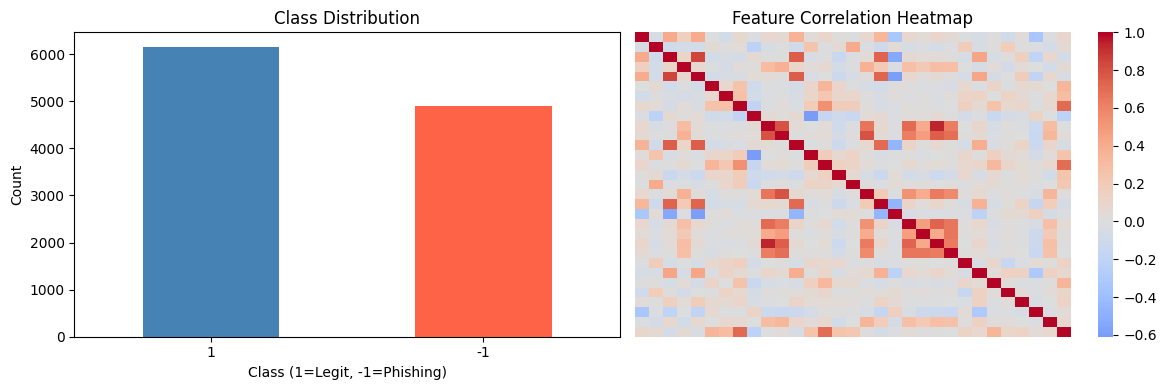

In [6]:
# Cell 3 — EDA

# Fix target column & drop Index
df = df.drop(columns=['Index'])

print("Class distribution:")
print(df['class'].value_counts())
print("\n1 = Legitimate | -1 = Phishing")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 — Class balance
df['class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class (1=Legit, -1=Phishing)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2 — Correlation heatmap
sns.heatmap(df.corr(), cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [7]:
# Cell 4 — Feature Engineering & Train/Test Split

# Separate features and target
X = df.drop(columns=['class'])
y = df['class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain class distribution:")
print(y_train.value_counts())

Features shape: (11054, 30)
Target shape: (11054,)

Train size: 8843
Test size: 2211

Train class distribution:
class
 1    4925
-1    3918
Name: count, dtype: int64


In [8]:
# Cell 5 — Model Training

# Baseline: Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42) #giving 1000 itertion too finish properly
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

# Main model: Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy:       {rf_acc:.4f}")

# Quick comparison
print("\n--- Model Comparison ---")
print(f"Logistic Regression: {lr_acc*100:.2f}%")
print(f"Random Forest:       {rf_acc*100:.2f}%")
print(f"Improvement:         +{(rf_acc - lr_acc)*100:.2f}%")

Training Logistic Regression...
Logistic Regression Accuracy: 0.9389

Training Random Forest...
Random Forest Accuracy:       0.9738

--- Model Comparison ---
Logistic Regression: 93.89%
Random Forest:       97.38%
Improvement:         +3.48%


In [9]:
# Quick experiment — 100 vs 200 trees
import time

for n in [100, 200]:
    start = time.time()
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    elapsed = time.time() - start
    acc = accuracy_score(y_test, preds)
    print(f"n_estimators={n}: Accuracy={acc*100:.2f}%  Time={elapsed:.2f}s")

n_estimators=100: Accuracy=97.38%  Time=0.17s
n_estimators=200: Accuracy=97.38%  Time=0.30s


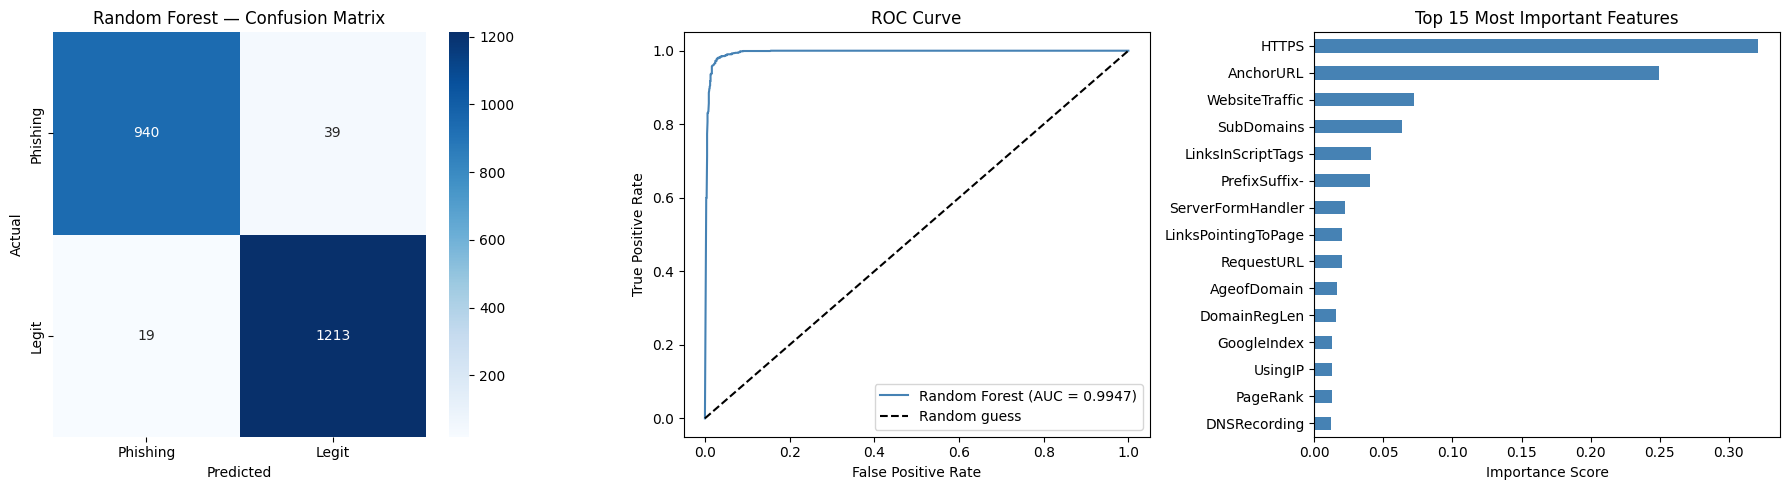


Classification Report — Random Forest:
              precision    recall  f1-score   support

    Phishing       0.98      0.96      0.97       979
       Legit       0.97      0.98      0.98      1232

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [10]:
# Cell 6 — Model Evaluation

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Phishing', 'Legit'],
            yticklabels=['Phishing', 'Legit'])
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# --- ROC Curve ---
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_probs, pos_label=1)
auc = roc_auc_score(y_test, rf_probs)
axes[1].plot(fpr, tpr, color='steelblue', label=f'Random Forest (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random guess')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# --- Feature Importance ---
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().tail(15).plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 15 Most Important Features')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report — Random Forest:")
print(classification_report(y_test, rf_preds, target_names=['Phishing', 'Legit']))

In [11]:
# Cell 7 — Live URL Predictor

import re
import urllib.parse

def extract_features(url):
    """Extract the same 30 features from a raw URL for prediction."""
    features = {}

    # UsingIP — does the URL use an IP address instead of domain?
    features['UsingIP'] = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else -1

    # LongURL — is the URL suspiciously long?
    features['LongURL'] = 1 if len(url) >= 54 else -1

    # ShortURL — is it a shortened URL?
    shorteners = ['bit.ly', 'tinyurl', 'goo.gl', 't.co', 'ow.ly', 'is.gd']
    features['ShortURL'] = 1 if any(s in url for s in shorteners) else -1

    # Symbol@ — does it contain @ symbol?
    features['Symbol@'] = 1 if '@' in url else -1

    # Redirecting// — does it have // redirection?
    features['Redirecting//'] = 1 if url.rfind('//') > 7 else -1

    # PrefixSuffix- — does domain contain a dash?
    domain = urllib.parse.urlparse(url).netloc
    features['PrefixSuffix-'] = 1 if '-' in domain else -1

    # SubDomains — how many subdomains?
    subdomains = domain.split('.')
    features['SubDomains'] = 1 if len(subdomains) > 3 else -1

    # HTTPS — does it use HTTPS?
    features['HTTPS'] = 1 if url.startswith('https') else -1

    # DomainRegLen — is domain short (suspicious)?
    features['DomainRegLen'] = 1 if len(domain) > 15 else -1

    # Remaining features — set to -1 (legitimate) as defaults
    # (these require live page scraping which is beyond scope)
    defaults = ['Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL',
                'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler',
                'InfoEmail', 'AbnormalURL', 'WebsiteForwarding',
                'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow',
                'IframeRedirection', 'AgeofDomain', 'DNSRecording',
                'WebsiteTraffic', 'PageRank', 'GoogleIndex',
                'LinksPointingToPage', 'StatsReport']
    for f in defaults:
        features[f] = -1

    return pd.DataFrame([features])


def predict_url(url):
    """Predict whether a URL is phishing or legitimate."""
    features = extract_features(url)
    features = features[X.columns]  # ensure correct column order
    prediction = rf_model.predict(features)[0]
    probability = rf_model.predict_proba(features)[0]

    print(f"\nURL: {url}")
    print(f"Prediction : {'✅ Legitimate' if prediction == 1 else '🚨 PHISHING'}")
    print(f"Confidence : {max(probability)*100:.2f}%")
    print("-" * 50)


# --- Test it out ---
predict_url("https://www.google.com")
predict_url("http://192.168.1.1/login/bank@secure.com")
predict_url("https://paypal.com.suspicious-login.xyz/verify")
predict_url("http://bit.ly/3xFakeBank")


URL: https://www.google.com
Prediction : 🚨 PHISHING
Confidence : 81.00%
--------------------------------------------------

URL: http://192.168.1.1/login/bank@secure.com
Prediction : 🚨 PHISHING
Confidence : 99.00%
--------------------------------------------------

URL: https://paypal.com.suspicious-login.xyz/verify
Prediction : ✅ Legitimate
Confidence : 51.00%
--------------------------------------------------

URL: http://bit.ly/3xFakeBank
Prediction : 🚨 PHISHING
Confidence : 99.00%
--------------------------------------------------
